## **Exploratory Data Analysis & Data Preparation**

#### **Objectives**
- Load and explore the resume dataset
- Perform comprehensive EDA
- Assess data quality
- Clean and prepare data for modeling

In [5]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
# Load dataset
df = pd.read_csv('dataset/resumeJD_pairs.csv', engine='python', on_bad_lines='skip')
print(f"Data Loaded Successfully: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")

Data Loaded Successfully: 320 rows, 4 columns

Columns: ['resume_text', 'job_description', 'match_score', 'match_label']


In [7]:
# First look at the data
print("First 5 rows:")
df.head()

First 5 rows:


,resume_text,job_description,match_score,match_label
0,Senior data analyst with 6 years of experience...,Senior Business Intelligence Analyst at enterp...,0.90,high
1,Full stack developer with 5 years of experienc...,Full Stack Engineer at startup. Required skill...,0.92,high
2,Cybersecurity analyst with 5 years of experien...,Cybersecurity Analyst at enterprise firm. Requ...,0.88,high
3,Sales manager with 7 years of experience in B2...,Sales Manager at SaaS company. Required skills...,0.91,high
4,Healthcare analyst with 4 years of experience ...,Healthcare Data Analyst at hospital network. R...,0.87,high


In [8]:
# dataset information
print("Dataset Info:")
print("=" * 60)
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resume_text      318 non-null    object 
 1   job_description  316 non-null    object 
 2   match_score      320 non-null    float64
 3   match_label      320 non-null    object 
dtypes: float64(1), object(3)
memory usage: 10.1+ KB


In [9]:
# statistical summary
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,match_score
count,320.000000
mean,0.863406
std,5.514498
min,-0.200000
25%,0.140000
50%,0.550000
75%,0.900000
max,99.000000


In [10]:
# text columns summary
print("\nText Columns Summary:")
df.describe(include='object')


Text Columns Summary:


,resume_text,job_description,match_label
count,318,316,320
unique,316,301,6
top,Backend engineer with 5 years of experience bu...,Backend Engineer at a fast-growing e-commerce ...,high
freq,3,3,125


In [11]:
# Check for the missing values
print("Missing Values Analysis:")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})
print(missing_df)
print(f"\nTotal missing values: {missing.sum()}")

Missing Values Analysis:
                 Missing_Count  Percentage
resume_text                  2       0.625
job_description              4       1.250
match_score                  0       0.000
match_label                  0       0.000

Total missing values: 6


In [12]:
full_dupes = df.duplicated().sum()
print(f"Full duplicate rows: {full_dupes}")

Full duplicate rows: 2


In [13]:
pair_dupes = df.duplicated(subset=['resume_text', 'job_description']).sum()
print(f"Duplicate resume+JD pairs: {pair_dupes}")

Duplicate resume+JD pairs: 2


In [14]:
print("\nDuplicate rows:")
df[df.duplicated(subset=['resume_text', 'job_description'], keep=False)]


Duplicate rows:


,resume_text,job_description,match_score,match_label
220,Backend engineer with 5 years of experience bu...,Backend Engineer at a fast-growing e-commerce ...,0.91,high
230,Backend engineer with 5 years of experience bu...,Backend Engineer at a fast-growing e-commerce ...,0.91,high
260,Backend engineer with 5 years of experience bu...,Backend Engineer at a fast-growing e-commerce ...,0.91,high


In [15]:
# ─── Section: Uniqueness Checks ───────────────────────────────────────────────

print(f"Total rows:          {len(df)}")
print(f"Unique resumes:      {df['resume_text'].nunique()}")
print(f"Unique JDs:          {df['job_description'].nunique()}")
print(f"Unique resume+JD pairs: {df[['resume_text','job_description']].drop_duplicates().shape[0]}")


Total rows:          320
Unique resumes:      316
Unique JDs:          301
Unique resume+JD pairs: 318


In [16]:
# ─── Section: Label Consistency ───────────────────────────────────────────────

# What labels exist? (spot the case inconsistency!)
print("Unique labels found:")
print(df['match_label'].value_counts())

# Is the casing consistent?
print(f"\nExpected 3 labels, got: {df['match_label'].nunique()} unique values")
print("Distinct values:", df['match_label'].unique())


Unique labels found:
match_label
high      125
medium     98
low        93
HIGH        2
High        1
MEDIUM      1
Name: count, dtype: int64

Expected 3 labels, got: 6 unique values
Distinct values: ['high' 'medium' 'low' 'HIGH' 'High' 'MEDIUM']


In [17]:
print("Score distribution:")
print(df['match_score'].describe())
print()

# Scores must be between 0.0 and 1.0 — flag the bad ones
invalid_scores = df[(df['match_score'] < 0) | (df['match_score'] > 1)]
print(f"Invalid scores (out of 0–1 range): {len(invalid_scores)}")
print(invalid_scores[['match_label', 'match_score']])


Score distribution:
count    320.000000
mean       0.863406
std        5.514498
min       -0.200000
25%        0.140000
50%        0.550000
75%        0.900000
max       99.000000
Name: match_score, dtype: float64

Invalid scores (out of 0–1 range): 6
    match_label  match_score
247      medium         2.30
261        high         1.50
262        high        -0.20
266         low        99.00
309        high         1.20
319        high        -0.05


In [18]:
# ─── Section: Label vs Score Sanity Check ─────────────────────────────────────
# Do scores actually match what the label says?

print("Score stats per label (after lowercasing):")
df['match_label_lower'] = df['match_label'].str.lower()
print(df.groupby('match_label_lower')['match_score'].describe().round(2))

# Expected:
#   high   → 0.75 – 0.95
#   medium → 0.40 – 0.70
#   low    → 0.05 – 0.35


Score stats per label (after lowercasing):
                   count  mean    std   min   25%   50%   75%   max
match_label_lower                                                  
high               128.0  0.88   0.17 -0.20  0.89  0.90  0.92   1.5
low                 93.0  1.19  10.25  0.05  0.07  0.09  0.12  99.0
medium              99.0  0.54   0.19  0.40  0.48  0.50  0.57   2.3


In [19]:
# ─── Section: Null Values ─────────────────────────────────────────────────────

print("Missing values per column:")
print(df.isnull().sum())
print()

# Show the rows with nulls
nulls = df[df.isnull().any(axis=1)]
print(f"Rows with at least one null: {len(nulls)}")
nulls[['match_label', 'match_score']].head(10)


Missing values per column:
resume_text          2
job_description      4
match_score          0
match_label          0
match_label_lower    0
dtype: int64

Rows with at least one null: 6


,match_label,match_score
235,high,0.90
271,medium,0.48
273,high,0.79
294,high,0.88
303,high,0.85
315,high,0.87


In [20]:
# ─── Summary: All issues found ────────────────────────────────────────────────

print("=" * 50)
print("DATA QUALITY REPORT — merged_dataset.csv")
print("=" * 50)
print(f"  Total rows:             {len(df)}")
print(f"  Full duplicates:        {df.duplicated().sum()}")
print(f"  Duplicate pairs:        {df.duplicated(subset=['resume_text','job_description']).sum()}")
print(f"  Null resume_text:       {df['resume_text'].isnull().sum()}")
print(f"  Null job_description:   {df['job_description'].isnull().sum()}")
print(f"  Label case variants:    {df['match_label'].nunique()} (expected 3)")
print(f"  Invalid scores (<0/>1): {((df['match_score'] < 0) | (df['match_score'] > 1)).sum()}")
print("=" * 50)

DATA QUALITY REPORT — merged_dataset.csv
  Total rows:             320
  Full duplicates:        2
  Duplicate pairs:        2
  Null resume_text:       2
  Null job_description:   4
  Label case variants:    6 (expected 3)
  Invalid scores (<0/>1): 6


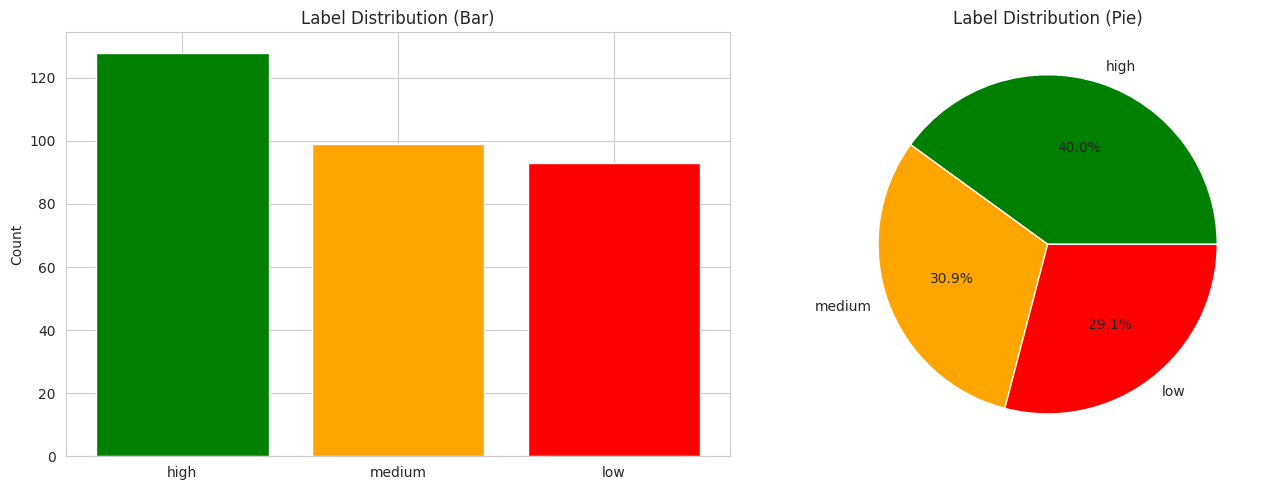

In [21]:
# Pie chart + bar side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['match_label'].str.lower().value_counts()

axes[0].bar(counts.index, counts.values, color=['green','orange','red'])
axes[0].set_title('Label Distribution (Bar)')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['green','orange','red'])
axes[1].set_title('Label Distribution (Pie)')

plt.tight_layout()
plt.show()


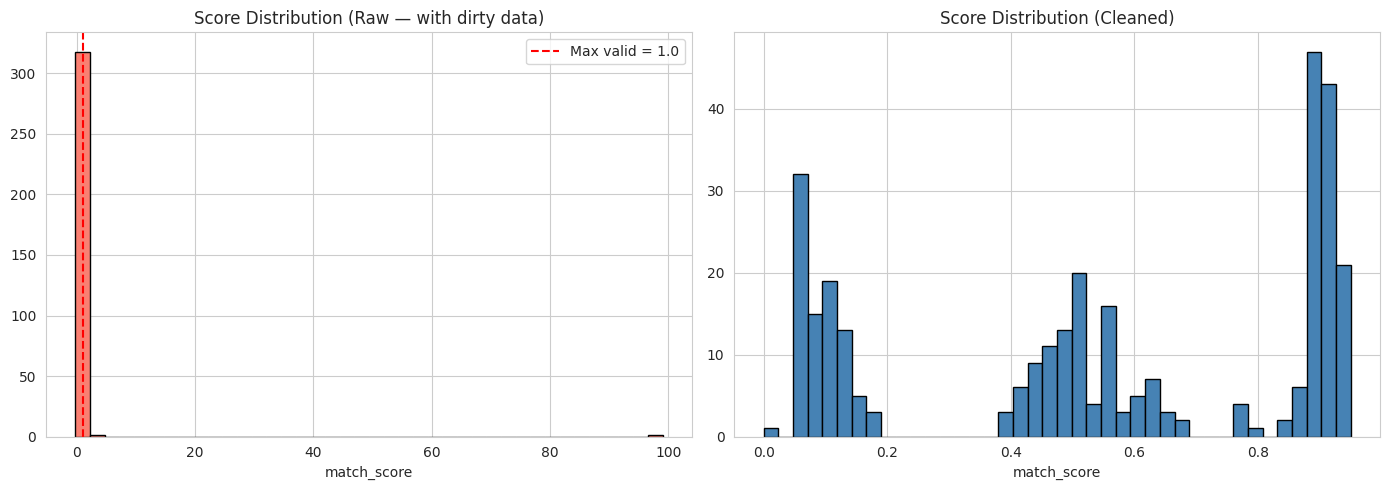

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before cleaning
axes[0].hist(df['match_score'], bins=40, color='salmon', edgecolor='black')
axes[0].set_title('Score Distribution (Raw — with dirty data)')
axes[0].set_xlabel('match_score')
axes[0].axvline(1.0, color='red', linestyle='--', label='Max valid = 1.0')
axes[0].legend()

# After cleaning
clean = df[(df['match_score'] >= 0) & (df['match_score'] <= 1)]
axes[1].hist(clean['match_score'], bins=40, color='steelblue', edgecolor='black')
axes[1].set_title('Score Distribution (Cleaned)')
axes[1].set_xlabel('match_score')

plt.tight_layout()
plt.show()

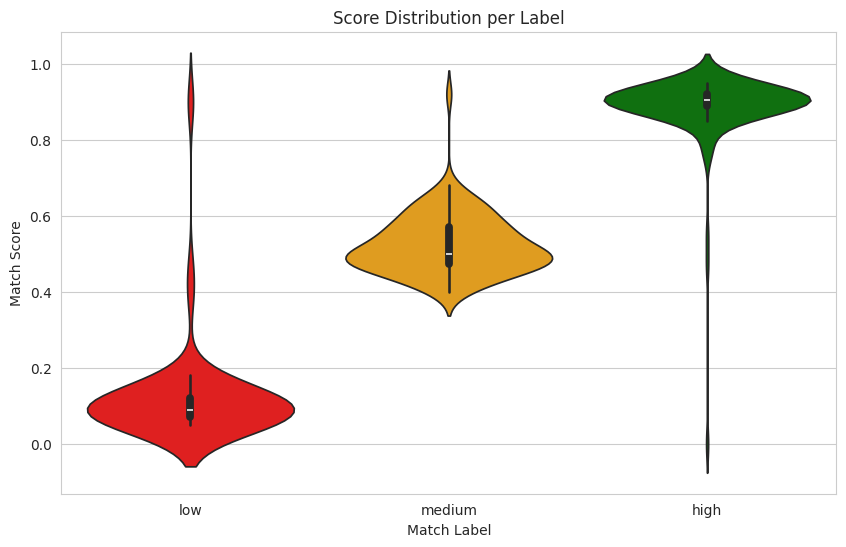

In [23]:
import seaborn as sns

df_plot = df.copy()
df_plot['match_label'] = df_plot['match_label'].str.lower()
df_plot = df_plot[(df_plot['match_score'] >= 0) & (df_plot['match_score'] <= 1)]

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_plot, x='match_label', y='match_score',
               order=['low','medium','high'],
               palette=['red','orange','green'])
plt.title('Score Distribution per Label')
plt.xlabel('Match Label')
plt.ylabel('Match Score')
plt.show()


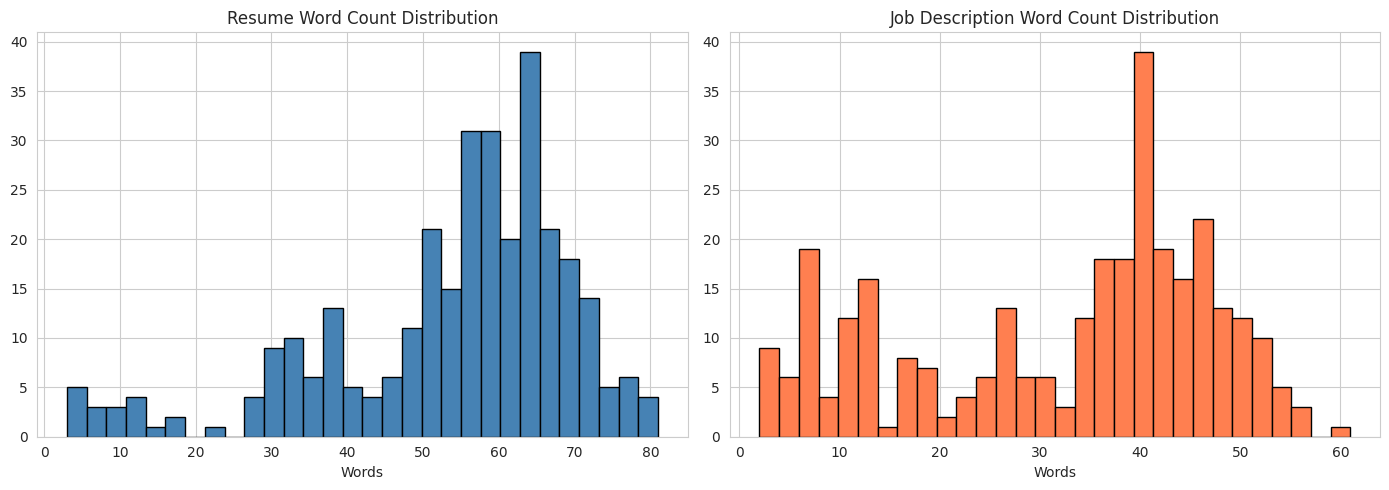

In [24]:
df_plot['resume_len'] = df_plot['resume_text'].str.split().str.len()
df_plot['jd_len']     = df_plot['job_description'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_plot['resume_len'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Resume Word Count Distribution')
axes[0].set_xlabel('Words')

axes[1].hist(df_plot['jd_len'], bins=30, color='coral', edgecolor='black')
axes[1].set_title('Job Description Word Count Distribution')
axes[1].set_xlabel('Words')

plt.tight_layout()
plt.show()

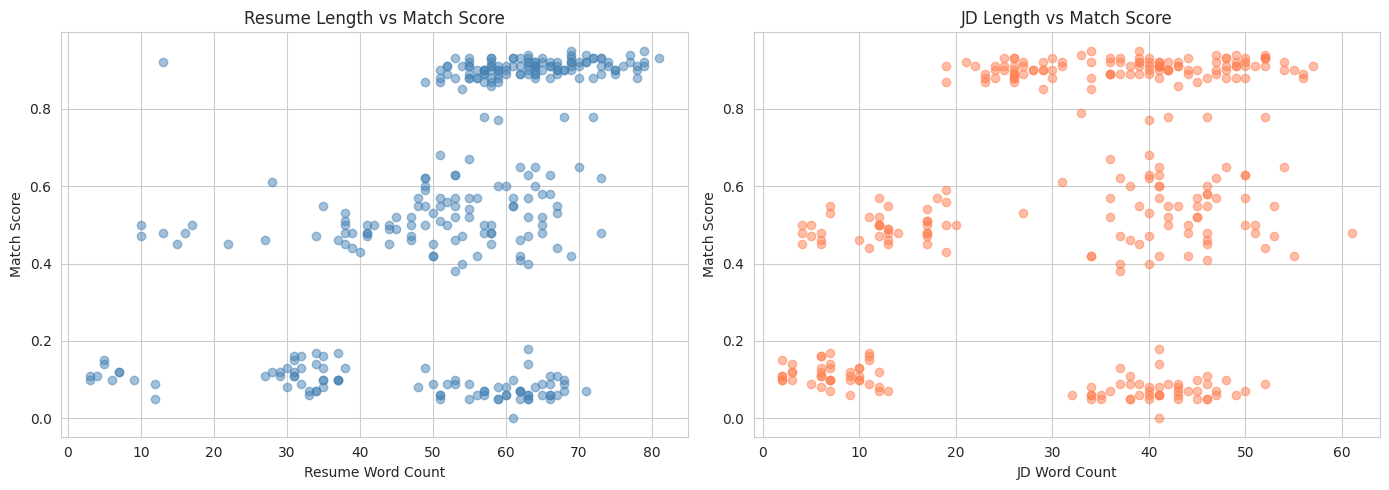

Resume length correlation: 0.482
JD length correlation:     0.343


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_plot['resume_len'], df_plot['match_score'], alpha=0.5, color='steelblue')
axes[0].set_xlabel('Resume Word Count')
axes[0].set_ylabel('Match Score')
axes[0].set_title('Resume Length vs Match Score')

axes[1].scatter(df_plot['jd_len'], df_plot['match_score'], alpha=0.5, color='coral')
axes[1].set_xlabel('JD Word Count')
axes[1].set_ylabel('Match Score')
axes[1].set_title('JD Length vs Match Score')

plt.tight_layout()
plt.show()

# Actual correlation values
print("Resume length correlation:", df_plot['resume_len'].corr(df_plot['match_score']).round(3))
print("JD length correlation:    ", df_plot['jd_len'].corr(df_plot['match_score']).round(3))


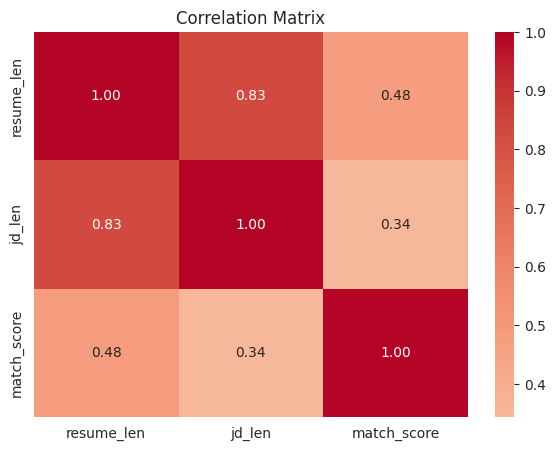

In [26]:
plt.figure(figsize=(7, 5))
corr = df_plot[['resume_len', 'jd_len', 'match_score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()


In [28]:
pip install wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.2/526.2 kB 11.3 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


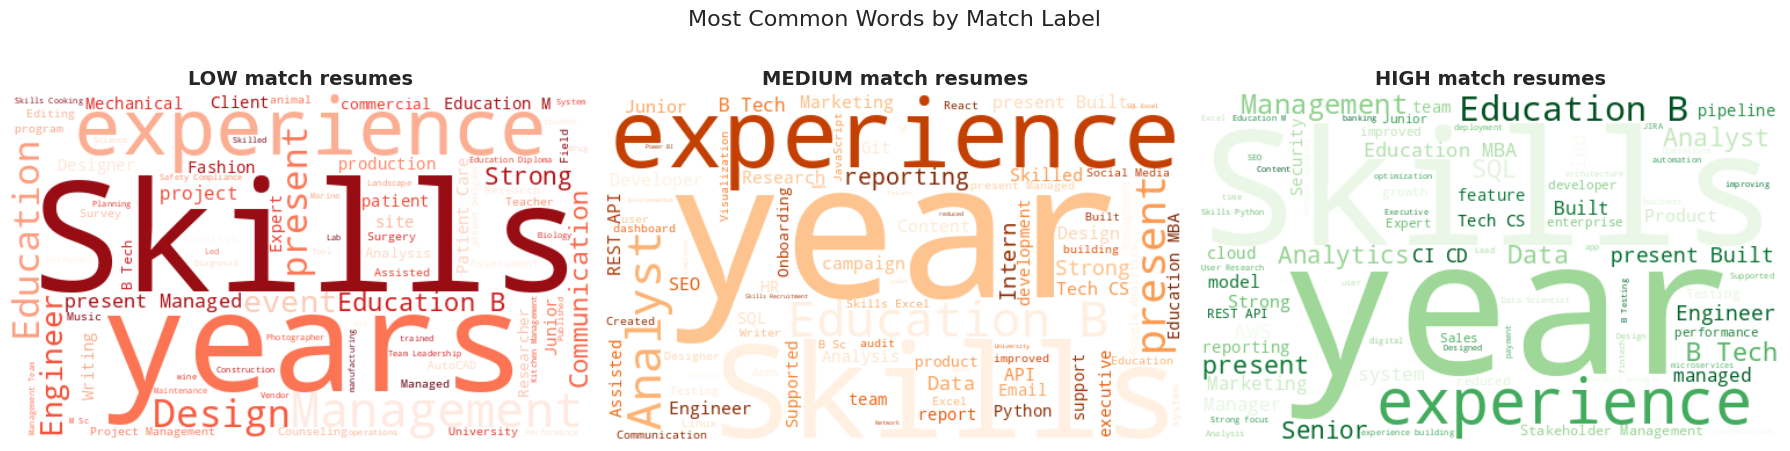

In [29]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels  = ['low', 'medium', 'high']
colors  = ['Reds', 'Oranges', 'Greens']

for ax, label, cmap in zip(axes, labels, colors):
    text = ' '.join(df_plot[df_plot['match_label'] == label]['resume_text'].dropna())
    wc = WordCloud(width=500, height=300, background_color='white',
                   colormap=cmap, max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label.upper()} match resumes', fontsize=14, fontweight='bold')

plt.suptitle('Most Common Words by Match Label', fontsize=16)
plt.tight_layout()
plt.show()


In [30]:
# Always record the starting point so that you  can see what changed
print("BEFORE CLEANING")
print("=" * 40)
print(f"Total rows:       {len(df)}")
print(f"Null resume_text: {df['resume_text'].isnull().sum()}")
print(f"Null job_desc:    {df['job_description'].isnull().sum()}")
print(f"Duplicates:       {df.duplicated().sum()}")
print(f"Label variants:   {df['match_label'].nunique()}")
print(f"Invalid scores:   {((df['match_score'] < 0) | (df['match_score'] > 1)).sum()}")

df_clean = df.copy()

BEFORE CLEANING
Total rows:       320
Null resume_text: 2
Null job_desc:    4
Duplicates:       2
Label variants:   6
Invalid scores:   6


In [31]:
# Problem: 'high', 'High', 'HIGH' are treated as 3 different categories
print("Before:", df_clean['match_label'].value_counts().to_dict())

df_clean['match_label'] = df_clean['match_label'].str.lower().str.strip()

print("After: ", df_clean['match_label'].value_counts().to_dict())
print(f"\nUnique labels now: {df_clean['match_label'].nunique()} (expected 3)")

Before: {'high': 125, 'medium': 98, 'low': 93, 'HIGH': 2, 'High': 1, 'MEDIUM': 1}
After:  {'high': 128, 'medium': 99, 'low': 93}

Unique labels now: 3 (expected 3)


In [32]:
print(f"Before dropping nulls: {len(df_clean)} rows")

df_clean = df_clean.dropna(subset=['resume_text', 'job_description'])

print(f"After dropping nulls:  {len(df_clean)} rows")
print(f"Removed: {len(df) - len(df_clean)} rows")

Before dropping nulls: 320 rows
After dropping nulls:  314 rows
Removed: 6 rows


In [33]:
print(f"Before removing duplicates: {len(df_clean)} rows")
print(f"Duplicate pairs found: {df_clean.duplicated(subset=['resume_text','job_description']).sum()}")

df_clean = df_clean.drop_duplicates(subset=['resume_text', 'job_description'], keep='first')

print(f"After removing duplicates:  {len(df_clean)} rows")

Before removing duplicates: 314 rows
Duplicate pairs found: 2
After removing duplicates:  312 rows


In [34]:
# Scores must be in [0.0, 1.0], anything else is a data error
invalid_mask = (df_clean['match_score'] < 0.0) | (df_clean['match_score'] > 1.0)
print(f"Invalid scores found: {invalid_mask.sum()}")
print(df_clean[invalid_mask][['match_label','match_score']])

df_clean = df_clean[~invalid_mask]
print(f"\nRows after removing invalid scores: {len(df_clean)}")

Invalid scores found: 6
    match_label  match_score
247      medium         2.30
261        high         1.50
262        high        -0.20
266         low        99.00
309        high         1.20
319        high        -0.05

Rows after removing invalid scores: 306


In [35]:
#are the scores consistent with what the label claims?
# Expected: low=0.05-0.35, medium=0.40-0.70, high=0.75-0.95

print("Score range per label:")
print(df_clean.groupby('match_label')['match_score'].agg(['min','max','mean']).round(2))

# Flag any rows where label and score contradict each other
def label_score_mismatch(row):
    score = row['match_score']
    label = row['match_label']
    if label == 'high'   and score < 0.70: return True
    if label == 'medium' and (score < 0.35 or score > 0.75): return True
    if label == 'low'    and score > 0.40: return True
    return False

mismatches = df_clean.apply(label_score_mismatch, axis=1)
print(f"\nLabel-score mismatches: {mismatches.sum()}")
df_clean[mismatches][['match_label','match_score']]

Score range per label:
              min   max  mean
match_label                  
high         0.00  0.95  0.89
low          0.05  0.92  0.12
medium       0.40  0.92  0.52

Label-score mismatches: 8


,match_label,match_score
225,medium,0.92
232,high,0.00
245,low,0.47
250,low,0.42
263,low,0.92
265,high,0.47
307,low,0.88
311,high,0.55


In [36]:
# A 15-character resume or JD is useless for training
df_clean['resume_len'] = df_clean['resume_text'].str.split().str.len()
df_clean['jd_len']     = df_clean['job_description'].str.split().str.len()

print("Short texts found:")
print(f"  resume_text < 20 words: {(df_clean['resume_len'] < 20).sum()}")
print(f"  job_description < 10 words: {(df_clean['jd_len'] < 10).sum()}")

df_clean = df_clean[(df_clean['resume_len'] >= 20) & (df_clean['jd_len'] >= 10)]
print(f"\nRows after removing short texts: {len(df_clean)}")

Short texts found:
  resume_text < 20 words: 18
  job_description < 10 words: 38

Rows after removing short texts: 266


In [37]:
df_clean = df_clean.reset_index(drop=True)

print("=" * 45)
print("CLEANING SUMMARY")
print("=" * 45)
print(f"  Original rows:        {len(df)}")
print(f"  Final rows:           {len(df_clean)}")
print(f"  Rows removed:         {len(df) - len(df_clean)}")
print()
print(f"  Nulls remaining:      {df_clean.isnull().sum().sum()}")
print(f"  Duplicates remaining: {df_clean.duplicated().sum()}")
print(f"  Label variants:       {df_clean['match_label'].nunique()}")
print(f"  Score range:          {df_clean['match_score'].min()} – {df_clean['match_score'].max()}")
print()
print("Label distribution after cleaning:")
print(df_clean['match_label'].value_counts())
print("=" * 45)

CLEANING SUMMARY
  Original rows:        320
  Final rows:           266
  Rows removed:         54

  Nulls remaining:      0
  Duplicates remaining: 0
  Label variants:       3
  Score range:          0.0 – 0.95

Label distribution after cleaning:
match_label
high      116
medium     87
low        63
Name: count, dtype: int64


In [38]:
# Drop the helper columns we added during EDA
df_clean.to_csv('dataset/cleaned_resumeJD_pairs.csv', index=False)
print(f"Saved: dataset/cleaned_resumeJD_pairs.csv ({len(df_clean)} rows)")

Saved: dataset/cleaned_resumeJD_pairs.csv (266 rows)
